# Revisions analyses

## imports and paths

In [1]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import os
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
original = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_OA.tsv"), separator="\t")
tempdir = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/"
figdir = cd + "results/manuscript_figures/revisions/"
mpra = original.filter(pl.col("z_score").is_not_null())
os.makedirs(tempdir, exist_ok=True)

## 1.1 Setting a DNA count threshold to investigate integration site effects

In [2]:
minDNAcount1 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount1_OA.tsv"), separator="\t")
minDNAcount2 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount2_OA.tsv"), separator="\t")
minDNAcount3 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount3_OA.tsv"), separator="\t")
minDNAcount4 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount4_OA.tsv"), separator="\t")
minDNAcount5 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount5_OA.tsv"), separator="\t")
minDNAcount6 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount6_OA.tsv"), separator="\t")
minDNAcount10 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount10_OA.tsv"), separator="\t")

In [7]:
joint_original_minDNAcounts1 = minDNAcount1.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts2 = minDNAcount2.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts3 = minDNAcount3.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts4 = minDNAcount4.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")	

joint_original_minDNAcounts5 = minDNAcount5.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts6 = minDNAcount6.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts10 = minDNAcount10.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")	

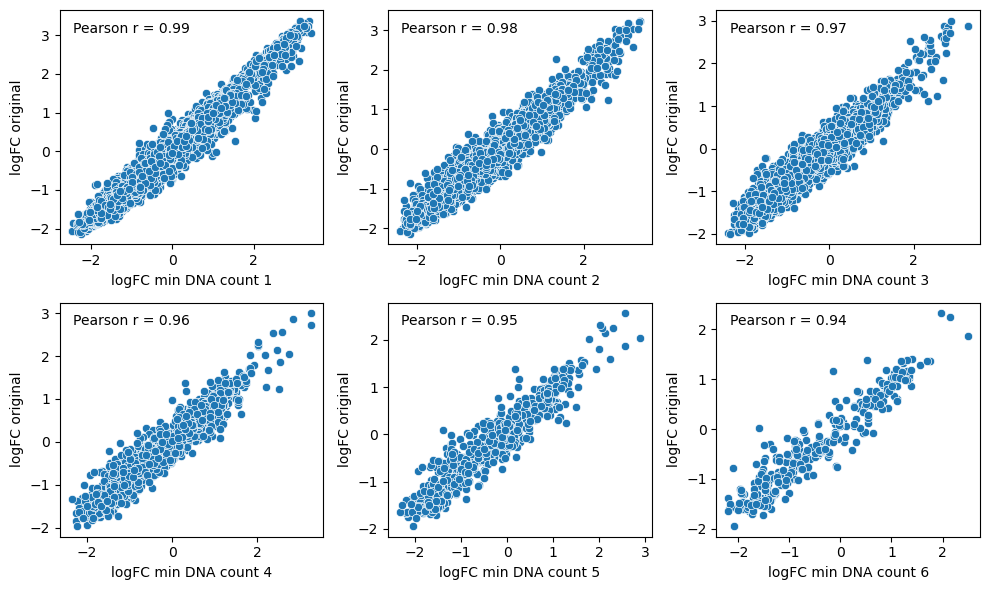

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

sns.scatterplot(
	data=joint_original_minDNAcounts1.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][0]
)
axes[0][0].set_xlabel("logFC min DNA count 1")
axes[0][0].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts2.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][1]
)
axes[0][1].set_xlabel("logFC min DNA count 2")
axes[0][1].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts3.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][2]
)
axes[0][2].set_xlabel("logFC min DNA count 3")
axes[0][2].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts4.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][0]
)
axes[1][0].set_xlabel("logFC min DNA count 4")
axes[1][0].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts5.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][1]
)
axes[1][1].set_xlabel("logFC min DNA count 5")
axes[1][1].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts6.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][2]
)
axes[1][2].set_xlabel("logFC min DNA count 6")
axes[1][2].set_ylabel("logFC original")

corrs = [
	joint_original_minDNAcounts1.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts2.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts4.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts6.select(pl.corr("logFC", "logFC_original")).item(),
]

for i, ax in enumerate(axes.flatten()):
	ax.text(
		0.05, 0.95,
		f"Pearson r = {corrs[i]:.2f}",
		transform=ax.transAxes,
		fontsize=10,
		verticalalignment='top',
		#bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
	)
plt.tight_layout()
#plt.title("logFC comparison original vs minDNAcount3")
plt.savefig(figdir+"/different_DNA_count_thresholds.pdf", format="pdf")

In [20]:
joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts10.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original"))

(shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.968742 ┆ 0.714213 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.948822 ┆ 0.491722 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌─────────┬─────────┐
 │ logFC   ┆ z_score │
 │ ---     ┆ ---     │
 │ f64     ┆ f64     │
 ╞═════════╪═════════╡
 │ 0.97058 ┆ NaN     │
 └─────────┴─────────┘)

In [51]:
# Calculate Jaccard index between 'effect' and 'effect_original'

def rowwise_jaccard_index(df):
	effect = df["effect"].to_list()
	effect_original = df["effect_original"].to_list()
	matches = sum(e == o for e, o in zip(effect, effect_original) if e is not None and e != 'no effect')
	non_matches = sum(e != o for e, o in zip(effect, effect_original) if e is not None and o is not None)
	total = matches + non_matches
	print(matches, non_matches)
	return matches / total if total > 0 else float('nan')


jaccard_index_rowwise_3 = rowwise_jaccard_index(joint_original_minDNAcounts3)
print("Row-wise Jaccard index (minDNAcount3):", jaccard_index_rowwise_3)

jaccard_index_rowwise_5 = rowwise_jaccard_index(joint_original_minDNAcounts5)
print("Row-wise Jaccard index (minDNAcount5):", jaccard_index_rowwise_5)

jaccard_index_rowwise_10 = rowwise_jaccard_index(joint_original_minDNAcounts10)
print("Row-wise Jaccard index (minDNAcount10):", jaccard_index_rowwise_10)

11 45
Row-wise Jaccard index (minDNAcount3): 0.19642857142857142
0 3
Row-wise Jaccard index (minDNAcount5): 0.0
0 0
Row-wise Jaccard index (minDNAcount10): nan


In [49]:
print("Unique values per dataframe:")
print(f"joint_original_minDNAcounts1: {joint_original_minDNAcounts1.n_unique()}")
print(f"joint_original_minDNAcounts2: {joint_original_minDNAcounts2.n_unique()}")
print(f"joint_original_minDNAcounts3: {joint_original_minDNAcounts3.n_unique()}")
print(f"joint_original_minDNAcounts4: {joint_original_minDNAcounts4.n_unique()}")
print(f"joint_original_minDNAcounts5: {joint_original_minDNAcounts5.n_unique()}")
print(f"joint_original_minDNAcounts6: {joint_original_minDNAcounts6.n_unique()}")
print(f"original: {original.n_unique()}")

Unique values per dataframe:
joint_original_minDNAcounts1: 27439
joint_original_minDNAcounts2: 11318
joint_original_minDNAcounts3: 4358
joint_original_minDNAcounts4: 1750
joint_original_minDNAcounts5: 741
joint_original_minDNAcounts6: 301
original: 83501


### Doing the same for the minP as a comparison

In [14]:
minp = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs.tsv.gz"), separator="\t")
minpDNAcount1 = minp
minpDNAcount2 = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_minDNAcount2.tsv.gz"), separator="\t", infer_schema_length=10000)
minpDNAcount3 = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_minDNAcount3.tsv.gz"), separator="\t", infer_schema_length=10000)
minpDNAcount4 = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_minDNAcount4.tsv.gz"), separator="\t", infer_schema_length=10000)
minpDNAcount5 = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_minDNAcount5.tsv.gz"), separator="\t", infer_schema_length=10000)
minpDNAcount6 = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_minDNAcount6.tsv.gz"), separator="\t", infer_schema_length=10000)

In [15]:
joint_minp_minDNAcounts1 = minpDNAcount1.join(
	minp, on=["oligo_name"], suffix="_original")

joint_minp_minDNAcounts2 = minpDNAcount2.join(
	minp, on=["oligo_name"], suffix="_original")

joint_minp_minDNAcounts3 = minpDNAcount3.join(
	minp, on=["oligo_name"], suffix="_original")

joint_minp_minDNAcounts4 = minpDNAcount4.join(
	minp, on=["oligo_name"], suffix="_original")

joint_minp_minDNAcounts5 = minpDNAcount5.join(
	minp, on=["oligo_name"], suffix="_original")

joint_minp_minDNAcounts6 = minpDNAcount6.join(
	minp, on=["oligo_name"], suffix="_original")

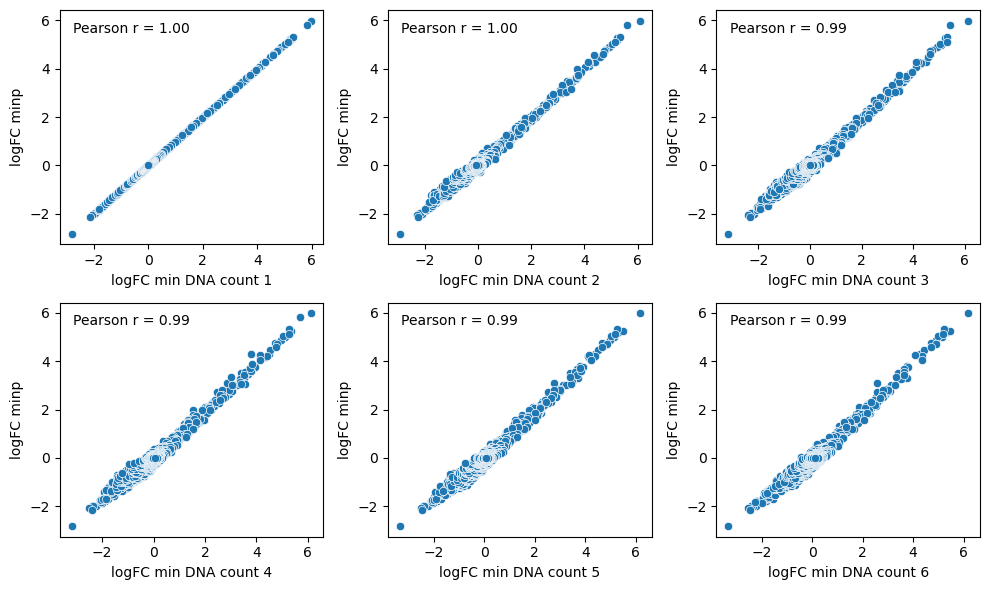

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

sns.scatterplot(
	data=joint_minp_minDNAcounts1.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][0]
)
axes[0][0].set_xlabel("logFC min DNA count 1")
axes[0][0].set_ylabel("logFC minp")

sns.scatterplot(
	data=joint_minp_minDNAcounts2.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][1]
)
axes[0][1].set_xlabel("logFC min DNA count 2")
axes[0][1].set_ylabel("logFC minp")

sns.scatterplot(
	data=joint_minp_minDNAcounts3.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0][2]
)
axes[0][2].set_xlabel("logFC min DNA count 3")
axes[0][2].set_ylabel("logFC minp")

sns.scatterplot(
	data=joint_minp_minDNAcounts4.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][0]
)
axes[1][0].set_xlabel("logFC min DNA count 4")
axes[1][0].set_ylabel("logFC minp")

sns.scatterplot(
	data=joint_minp_minDNAcounts5.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][1]
)
axes[1][1].set_xlabel("logFC min DNA count 5")
axes[1][1].set_ylabel("logFC minp")

sns.scatterplot(
	data=joint_minp_minDNAcounts6.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1][2]
)
axes[1][2].set_xlabel("logFC min DNA count 6")
axes[1][2].set_ylabel("logFC minp")

corrs_minp = [
	joint_minp_minDNAcounts1.select(pl.corr("logFC", "logFC_original")).item(),
	joint_minp_minDNAcounts2.select(pl.corr("logFC", "logFC_original")).item(),
	joint_minp_minDNAcounts3.select(pl.corr("logFC", "logFC_original")).item(),
	joint_minp_minDNAcounts4.select(pl.corr("logFC", "logFC_original")).item(),
	joint_minp_minDNAcounts5.select(pl.corr("logFC", "logFC_original")).item(),
	joint_minp_minDNAcounts6.select(pl.corr("logFC", "logFC_original")).item(),
]

for i, ax in enumerate(axes.flatten()):
	ax.text(
		0.05, 0.95,
		f"Pearson r = {corrs_minp[i]:.2f}",
		transform=ax.transAxes,
		fontsize=10,
		verticalalignment='top',
		#bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
	)
plt.tight_layout()
#plt.title("logFC comparison minp vs minDNAcount3")
plt.savefig(figdir+"/different_minp_DNA_count_thresholds.pdf", format="pdf")

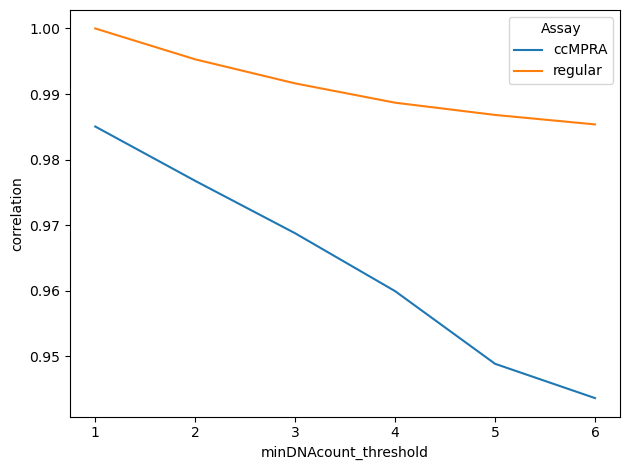

In [40]:
corr_df = pl.DataFrame({
	"minDNAcount_threshold": list(np.arange(1,7)) * 2,
	"correlation": corrs + corrs_minp,
	"Assay": ["ccMPRA"] * 6 + ["regular"] * 6
})

sns.lineplot(data=corr_df, x="minDNAcount_threshold", y="correlation", hue="Assay")

plt.tight_layout()
plt.savefig(figdir+"/different_DNA_count_thresholds_correlations.pdf", format="pdf")

## 2.2/2.3 Multiple BCs per sequence vs multiple sequences per bin

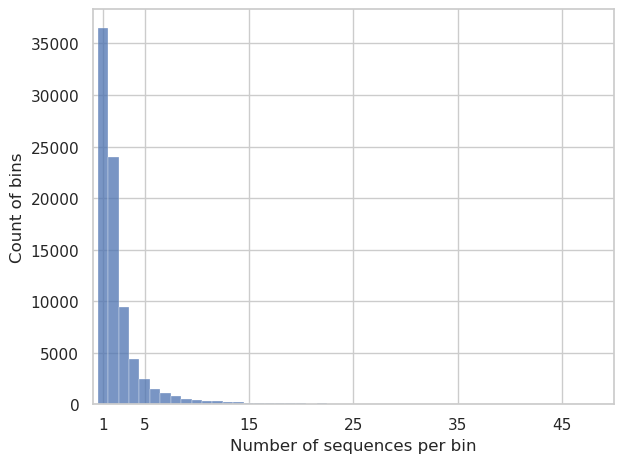

In [50]:
plt.xticks([1] + list(range(5,50, 10)))
sns.histplot(original.to_pandas(), x = "nr_seqs", bins=50, discrete=True)
plt.xlim(0,50)
plt.xlabel("Number of sequences per bin")
plt.ylabel("Count of bins")
plt.tight_layout()
plt.savefig(figdir+"/number_of_sequences_per_bin.pdf", format="pdf")

In [51]:
print("percentage of bins with one sequence:", round(original.filter(pl.col("nr_seqs") == 1).height * 100/original.height, 2), "%")

percentage of bins with one sequence: 43.73 %


In [52]:
original.filter(pl.col("right_bin").str.contains("null").not_()).filter(pl.col("z_score").is_not_null()).mean()

logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score
f64,f64,f64,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
-0.14087,0.112279,0.1035,null,null,12.754675,2.149999,null,null,null,null,null,null,null,null,null,154621.880196,null,null,null,null,-0.070059,inf,-0.08884


In [53]:
original.filter(pl.col("right_bin").str.contains("null")).filter(pl.col("targeted_left") != "unlabeled").mean()

logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score
f64,f64,f64,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
-0.277573,0.095013,0.087753,null,null,130.793212,18.996843,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [54]:
many_bcs = mpra.filter((pl.col("nr_seqs") == 1) & (pl.col("nr_reads") > 20))
many_seqs = mpra.filter((pl.col("nr_seqs") > 6) & (pl.col("nr_seqs") < 30) & (pl.col("nr_reads") < 40))

print(f"Number of barcodes with >20 barcodes and just 1 sequence: {many_bcs.height}")
print(f"Number of sequences with >10 sequences: {many_seqs.height}")

Number of barcodes with >20 barcodes and just 1 sequence: 691
Number of sequences with >10 sequences: 745


In [55]:
many_bcs.select("logFC", "z_score", "adj.P.Val", "nr_reads").mean()

logFC,z_score,adj.P.Val,nr_reads
f64,f64,f64,f64
0.137918,0.216859,0.0582,27.861071


In [56]:
many_seqs.select("logFC", "z_score", "adj.P.Val", "nr_reads", "nr_seqs").mean()

logFC,z_score,adj.P.Val,nr_reads,nr_seqs
f64,f64,f64,f64,f64
-0.211256,-0.348525,0.106507,29.485906,7.869799


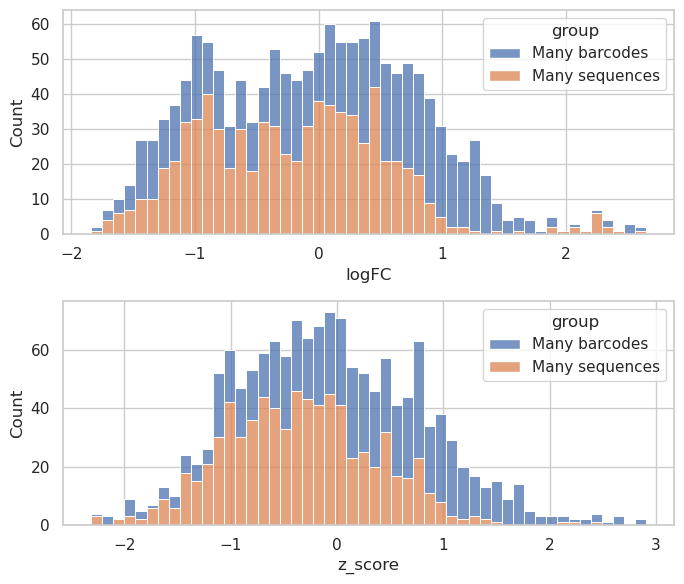

In [57]:
fig, axs = plt.subplots(2,1,figsize=(7, 6))

both = pl.concat([many_bcs, many_seqs]).with_columns(
	pl.when(pl.col("nr_seqs") == 1).then(pl.lit("Many barcodes")).otherwise(pl.lit("Many sequences")).alias("group")
)
sns.histplot(both.to_pandas(), x="logFC", bins=50, hue="group", multiple="stack", ax=axs[0])
sns.histplot(both.to_pandas(), x="z_score", bins=50, hue="group", multiple="stack", ax=axs[1])
plt.tight_layout()

<Axes: xlabel='logFC', ylabel='adj.P.Val'>

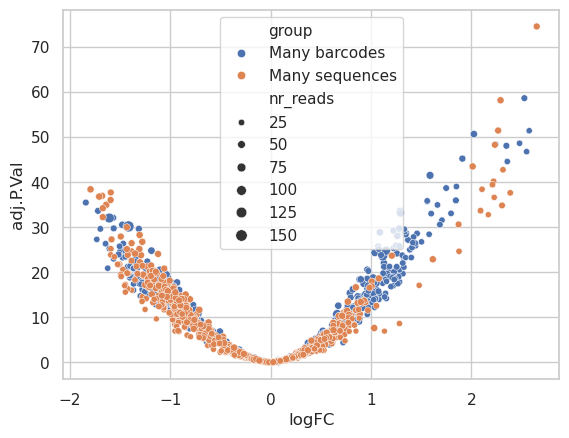

In [58]:
sns.scatterplot(both.with_columns(np.negative(np.log10(pl.col("adj.P.Val")))), x="logFC", y="adj.P.Val", hue="group", size="nr_reads")

### Looking at differences in sequence lengths and coordinates

#### Writing the files

In [59]:
mpra.select("left_bin", "right_bin").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [60]:

bins = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv"
seqids = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv"

In [61]:
# taking only those sequences that had assigned barcodes
!zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/mprasnakeflow/results/assigned_bcs_part1and2.tsv.gz' | cut -f -2,4,6,8,10,12,14 | awk 'NR > 1 && NF >=5' | cut -f 2 | sed 's/>//' > $seqids

In [62]:
# getting the original sequences for each bin
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
		| grep -Fwf <(sed 's/\t/S/' $bins) | sed 's/S/\t/' > "$tempdir""bins_with_seqs.tsv"

In [63]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv"

In [64]:
# Now taking only those sequences with assigned barcodes
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv" | sort | uniq -c | awk '{print $2"\t"$3"\t"$4"\t"$5"\t"$1}' | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv"

In [65]:
# getting the full sequence from the mapped file
!samtools view -N  <(cut -f 3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv") "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/merged_samples.tagged.bam" > \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam"

In [66]:
!awk -v OFS="\t" '{print $3,$4,$4 + length($10), $1}'  "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam" \
	> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

In [67]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam" 

m84066_240516_024507_s2/1117240/ccs	16	chr17	10422292	60	256M	*	0	0	CAGATACCCGGGGCACACGGCTGTCAGGGCCTTAAGCACGTTTCCTTATTTGCTACCACGGGAACCCCCCACTGCATTCCCTTGGGCCACTACAGATGCTCACTCTTGAAGTCCAGGCTTAGACAGCAGAGATTCTACCTTGAGTCTCCACCATTGGGCCAGTGCCCACTCATCTAACTTTGAAAAACATTATTAGTAGAAAATAATATGTTTATTACAGAAAAAAATACAGGTAAGTAAAAAAAGTCTCTGTAAG	IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII	NM:i:1	MD:Z:255T0	AS:i:255	XS:i:20	CT:Z:FAR	CO:Z:left
m84066_240516_024507_s2/1117240/ccs	0	chr17	10284356	60	207M	*	0	0	GATCAGCCTGGGCAACATAGTGAGAGCCCTGTCTCTACAAACAAACAAGCAAACAAAAAAATTAGCTAGCTAGGCTTGGTTGTGTGTGCATGTAGTCCCAGCTACTTGGGTGGCTGATGTGAGAGGATTGCTTGAGCCCAGGAGGTCGAAGCAGCTGTGGGCTGTGGTCATGCCACTGCATTCCAGCCCAGGTGACAGAGCAAGATC	IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [68]:
# Bins in the analyzed file are always sorted left to right, so doing that here too to make sure we can join on bins later
!sort -k4,4 -k2,2 -k3,3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed" | \
	awk -v OFS="\t" '{if ($4 == prev) print $1,prev_start,prev_end,$2,$3,$4; prev=$4; prev_start=$2; prev_end=$3}' \
		> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

In [69]:
!wc -l "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv" \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

   91652 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv
  183304 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed
  274956 total


In [70]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

chr2	99174657	99174970	99180852	99181320	V350161981_L02_contig_100096
chr20	5120285	5120874	5123279	5123477	V350161981_L02_contig_1002303
chr6	151451484	151452400	151452398	151452521	V350161981_L02_contig_1002493
chr12	111599592	111600282	111606115	111606178	V350161981_L02_contig_1002605
chr20	35456447	35456537	35742183	35742569	V350161981_L02_contig_1002901
chr13	45464674	45465113	45481041	45481352	V350161981_L02_contig_1006285
chr2	130835545	130835591	130835945	130836690	V350161981_L02_contig_100659
chr1	45521924	45522331	45537741	45537914	V350161981_L02_contig_1006693
chr6	11232214	11232701	11419894	11420071	V350161981_L02_contig_1007053
chr2	170715320	170715617	170717077	170717451	V350161981_L02_contig_1008084


#### Reading and analyzing the files

In [71]:
bins = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv", 
	separator="\t", columns=[0,1,2],has_header=False, new_columns=["left_bin", "right_bin", "seq_id"])
coords = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv", 
	separator="\t",has_header=False, new_columns=["chrom", "start_left", "end_left", "start_right", "end_right", "seq_id"]) \
	.with_columns(left_length = (pl.col("end_left") - pl.col("start_left") + 1),
	              right_length = (pl.col("end_right") - pl.col("start_right") + 1))

In [72]:
pl.Config.set_fmt_str_lengths(50)
bin_with_coords = bins.join(coords, on="seq_id")
bin_with_coords_stds = bin_with_coords.filter(pl.len().over("left_bin", "right_bin") > 1) \
	.group_by(["left_bin", "right_bin"]).agg(pl.col("left_length", "right_length").std()).unpivot(index=cs.matches("bin"), value_name="length std")


In [73]:
bin_with_coords_stds.head

<bound method DataFrame.head of shape: (58_412, 4)
┌─────────────────────────────┬─────────────────────────────┬──────────────┬────────────┐
│ left_bin                    ┆ right_bin                   ┆ variable     ┆ length std │
│ ---                         ┆ ---                         ┆ ---          ┆ ---        │
│ str                         ┆ str                         ┆ str          ┆ f64        │
╞═════════════════════════════╪═════════════════════════════╪══════════════╪════════════╡
│ chr14-20688098-20688455-+   ┆ chr14-20750530-20750634-.   ┆ left_length  ┆ 6.363961   │
│ chr19-48755166-48755632-+   ┆ chr19-48756212-48756421-.   ┆ left_length  ┆ 265.618712 │
│ chr2-171823866-171824038-.  ┆ chr2-171922550-171922902-+  ┆ left_length  ┆ 98.287843  │
│ chr5-149551131-149551444--  ┆ chr5-149555191-149555265-.  ┆ left_length  ┆ 191.625938 │
│ chr13-45460456-45460631-.   ┆ chr13-45464674-45465111-+   ┆ left_length  ┆ 1.258306   │
│ chr2-99180852-99181315-+    ┆ chr2-99190471-991

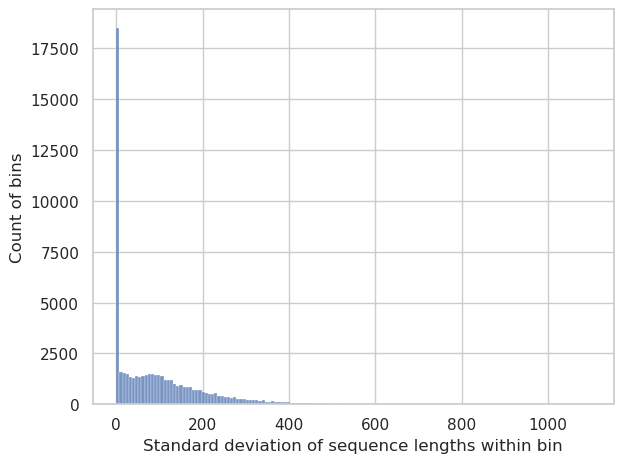

In [74]:
sns.histplot(bin_with_coords_stds.to_pandas(), x="length std")
plt.xlabel("Standard deviation of sequence lengths within bin")
plt.ylabel("Count of bins")
plt.tight_layout()
plt.savefig(figdir+"/sequence_length_std_within_bins.pdf", format="pdf")

In [126]:
bin_with_coords_stds.select(mean = pl.col("length std").mean(), median = pl.col("length std").median())

mean,median
f64,f64
93.334422,62.225397


In [75]:
bin_with_coords_stds.select(mean = pl.col("length std").mean(), med = pl.col("length std").median())

mean,med
f64,f64
93.334422,62.225397


In [76]:
bin_with_coords_stds.unique(["left_bin", "right_bin"]).filter(pl.col("length std") > 5).height / original.height

0.24324259589705513

In [77]:
print("percentage of bins with a length standard deviation <= 5:", round(bin_with_coords_stds.unique(["left_bin", "right_bin"]).filter(pl.col("length std") <= 5).height * 100/bin_with_coords_stds.unique(["left_bin", "right_bin"]).height, 2), "%")

percentage of bins with a length standard deviation <= 5: 30.46 %


In [78]:
bin_with_coords.filter(pl.col("left_bin") == "chr18-57621943-57622148--").filter(pl.col("right_bin") == "chr18-57624725-57624896-.")

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length
str,str,str,str,i64,i64,i64,i64,i64,i64
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240516_024507_s2/104468422/ccs""","""chr18""",57621943,57622153,57624728,57624903,211,176
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240516_024507_s2/84347061/ccs""","""chr18""",57621946,57622153,57624536,57624902,208,367
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240623_102831_s3/90574977/ccs""","""chr18""",57621943,57622152,57624534,57624899,210,366
"""chr18-57621943-57622148--""","""chr18-57624725-57624896-.""","""m84066_240623_122801_s1/54137738/ccs""","""chr18""",57621943,57622329,57624743,57624898,387,156


### Activity per individual sequence

In [79]:
per_sequence = pl.read_csv(os.path.join(cd, "mpra_capture_flow/results/CMPRA5/mpralm/prommoteroa_OA_mpralm_output_per_sequence.tsv"), separator="\t")
per_barcode = pl.read_csv(os.path.join(cd, "mpra_capture_flow/results/CMPRA5/mpralm/prommoteroa_OA_mpralm_output_per_barcode.tsv"), separator="\t")

In [80]:
per_barcode = per_barcode.with_columns(seq_id = pl.col("bin").str.split("-").list.get(0))

In [81]:
bin_with_coords.n_unique("seq_id")

91652

In [82]:
bin_with_coords.join(per_sequence, left_on="seq_id", right_on="bin").n_unique("seq_id") #.n_unique(["left_bin", "right_bin"]) 

47828

In [83]:
bin_with_coords.join(per_sequence, left_on="seq_id", right_on="bin").height

61197

In [84]:
bins.n_unique(["left_bin", "right_bin"]) 

56847

In [85]:
mpra.filter(pl.col("right_bin").str.contains("null").not_()).n_unique(["left_bin", "right_bin"]) 

56847

In [86]:
seqs_with_bins = bin_with_coords.join(per_sequence, left_on="seq_id", right_on="bin")

In [87]:
seqs_with_bins = seqs_with_bins.sort("left_bin", "right_bin", "seq_id").filter(pl.col("seq_id").len().over("left_bin", "right_bin") > 1) \
	.with_columns(std = pl.col("logFC").std().over("left_bin", "right_bin"), var = pl.col("logFC").var().over("left_bin", "right_bin"))

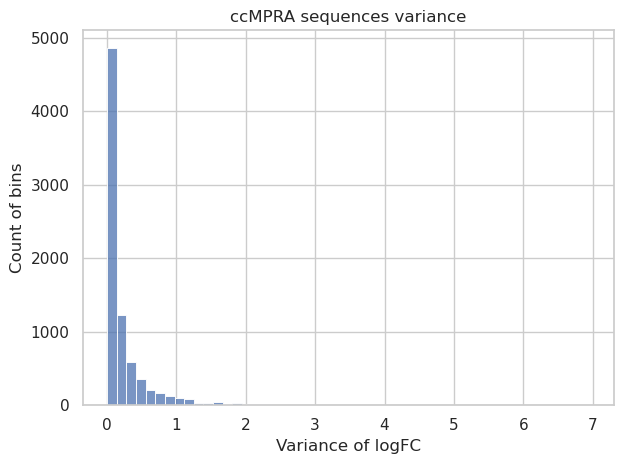

In [88]:
sns.histplot(seqs_with_bins.unique(["left_bin", "right_bin"]).to_pandas(), x="var", bins=50)
plt.xlabel("Variance of logFC")
plt.ylabel("Count of bins")
plt.title("ccMPRA sequences variance")
plt.tight_layout()
plt.savefig(figdir+"/ccMPRA_sequences_logFC_variance.pdf", format="pdf")

In [127]:
seqs_with_bins.select(mean = pl.col("var").mean(), median = pl.col("var").median())

mean,median
f64,f64
0.251873,0.107105


In [89]:
seqs_with_bins.unique(["left_bin", "right_bin"]).filter(pl.col("var") > 0.5).height / bin_with_coords.join(per_sequence, left_on="seq_id", right_on="bin").unique(["left_bin", "right_bin"]).height

0.02359761222334763

In [90]:
# to make sure we use the same sequences in both plots
per_barcode = per_barcode.join(seqs_with_bins, on="seq_id", how="semi")
# calculate std and variance
per_barcode = per_barcode.with_columns(std = pl.col("logFC").std().over("seq_id"), var = pl.col("logFC").var().over("seq_id"))

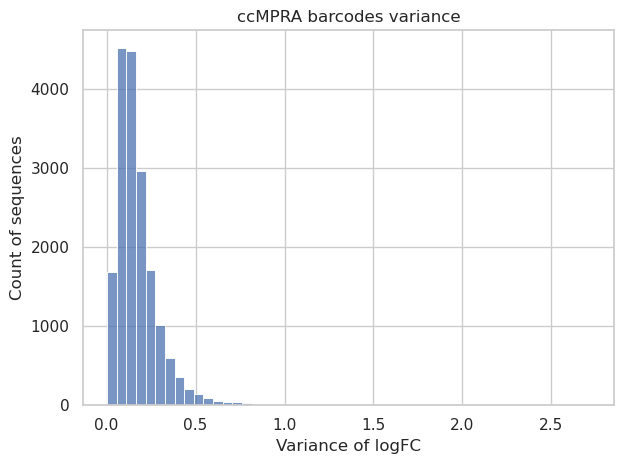

In [91]:
sns.histplot(per_barcode.unique(["seq_id"]).to_pandas(), x="var", bins=50)
plt.xlabel("Variance of logFC")
plt.ylabel("Count of sequences")
plt.title("ccMPRA barcodes variance")
plt.tight_layout()
plt.savefig(figdir+"/ccMPRA_barcodes_logFC_variance.pdf", format="pdf")

In [92]:
print("mean per_barcode:", per_barcode.select(pl.col("var").mean()).item(), "median per_barcode:", per_barcode.select(pl.col("var").median()).item())
print("mean seqs_with_bins:", seqs_with_bins.select(pl.col("var").mean()).item(), "median seqs_with_bins:", seqs_with_bins.select(pl.col("var").median()).item())

mean per_barcode: 0.17914653899319646 median per_barcode: 0.14815395972931109
mean seqs_with_bins: 0.25187270781541427 median seqs_with_bins: 0.10710527359996279


In [93]:
per_sequence_with_ccmpra = seqs_with_bins.sort("std", descending=True).join(mpra, on=["left_bin", "right_bin"], suffix="_ccmpra")

In [94]:
per_sequence_with_ccmpra.sort("std", descending=True).head(30).tail() #.unique(["promoter", "OE"])

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length,logFC,AveExpr,t,P.Value,adj.P.Val,B,std,var,logFC_ccmpra,adj.P.Val_ccmpra,P.Value_ccmpra,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std_ccmpra,z_score
str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
"""chr3-186781721-186782022-.""","""chr3-186783474-186783606-+""","""m84066_240623_102831_s3/46337518/ccs""","""chr3""",186781724,186782029,186783474,186784221,306,748,0.467391,0.467974,2.657534,0.009167,0.012899,-3.573047,2.136809,4.565953,0.456084,0.014799,0.010298,32,6,"""yes""","""pELS""","""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""EIF4A2""","""target - other""","""PLS - ELS""",1668.5,"""EIF4A2""","""no effect""","""chr3-186783474-186783606-+""","""chr3-186781721-186782022-.""",1.675155,0.76421,-1.595203
"""chr3-186783607-186784213-+""","""chr3-186843789-186843938-.""","""m84066_240516_024507_s2/188154902/ccs""","""chr3""",186783607,186784160,186843792,186843944,554,153,-1.208426,-1.211452,-7.487574,1.8012e-11,8.2558e-11,15.594602,2.129365,4.534197,-0.024505,0.914574,0.901225,16,2,"""yes""","""pELS,CTCF-bound,PLS,CTCF-bound""",null,"""target""","""unlabeled""","""EIF4A2""","""unlabeled""","""target - other""","""PLS - ELS""",59953.5,"""EIF4A2""","""no effect""","""chr3-186783607-186784213-+""","""chr3-186843789-186843938-.""",0.373563,0.619122,-0.642956
"""chr3-186783607-186784213-+""","""chr3-186843789-186843938-.""","""m84066_240623_122801_s1/211947769/ccs""","""chr3""",186783474,186784215,186843789,186843943,742,155,1.802952,1.803146,9.934472,3.5455e-16,3.4627e-15,26.381532,2.129365,4.534197,-0.024505,0.914574,0.901225,16,2,"""yes""","""pELS,CTCF-bound,PLS,CTCF-bound""",null,"""target""","""unlabeled""","""EIF4A2""","""unlabeled""","""target - other""","""PLS - ELS""",59953.5,"""EIF4A2""","""no effect""","""chr3-186783607-186784213-+""","""chr3-186843789-186843938-.""",0.373563,0.619122,-0.642956
"""chr17-75260480-75260597-.""","""chr17-75261259-75261403-+""","""V350161981_L02_contig_2621436""","""chr17""",75260478,75260599,75260598,75261408,122,811,-1.491611,-1.491799,-7.61687,2.0285e-11,9.2198e-11,15.634643,2.025228,4.101549,0.009193,0.967567,0.962022,17,3,"""no""","""pELS,CTCF-bound""","""pELS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""MRPS7""","""target - other""","""ELS - ELS""",792.5,"""MRPS7""","""no effect""","""chr17-75261259-75261403-+""","""chr17-75260480-75260597-.""",0.1973,0.918433,-0.204814
"""chr17-75260480-75260597-.""","""chr17-75261259-75261403-+""","""m84066_240623_122801_s1/143068765/ccs""","""chr17""",75260480,75260602,75261259,75261790,123,532,1.372494,1.372466,8.643344,9.2851e-14,6.1175e-13,20.865933,2.025228,4.101549,0.009193,0.967567,0.962022,17,3,"""no""","""pELS,CTCF-bound""","""pELS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""MRPS7""","""target - other""","""ELS - ELS""",792.5,"""MRPS7""","""no effect""","""chr17-75261259-75261403-+""","""chr17-75260480-75260597-.""",0.1973,0.918433,-0.204814


In [95]:
length_vs_std = seqs_with_bins.join(bin_with_coords_stds, on=["left_bin", "right_bin"])

In [96]:
length_vs_std.select(pl.corr("std", 'length std'))

std
f64
0.141352


<Axes: xlabel='length std', ylabel='std'>

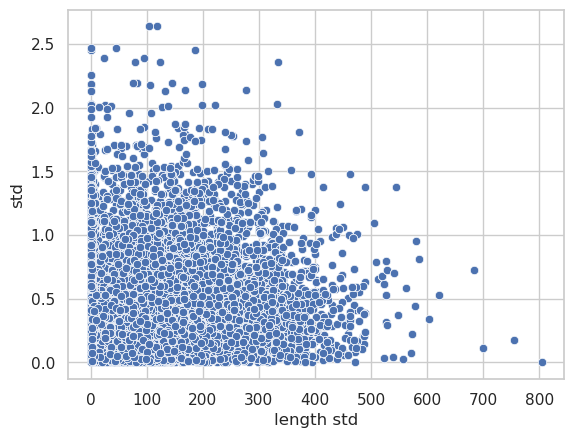

In [97]:
sns.scatterplot(length_vs_std.to_pandas(), x="length std", y="std")

#### Comparison to minP std

In [143]:
minp = pl.read_csv(os.path.join(cd, "results/CMPRA5_minP/BCalm/minP_logfcs_perbc.tsv.gz"), separator="\t")

In [144]:
minp = minp.with_columns(name=pl.col("oligo_name").str.reverse().str.splitn("_",2).struct[1].str.reverse(),
				  barcode = pl.col("oligo_name").str.split("_").list.get(-1))


In [145]:
minp = minp.with_columns(std = pl.col("logFC").std().over("name"), var= pl.col("logFC").var().over("name"))

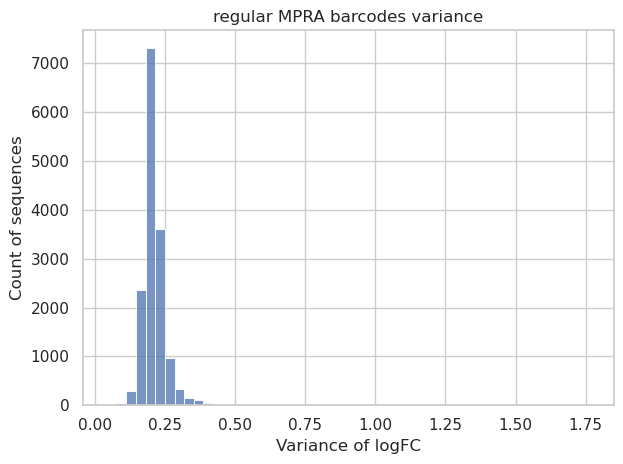

In [146]:
sns.histplot(minp.unique("name").to_pandas(), x="var", bins=50)
plt.xlabel("Variance of logFC")
plt.ylabel("Count of sequences")
plt.title("regular MPRA barcodes variance")
plt.tight_layout()
plt.savefig(figdir+"/regular_MPRA_barcodes_logFC_variance.pdf", format="pdf")

In [102]:
minp.select("var").median(), minp.select("var").mean()

(shape: (1, 1)
 ┌──────────┐
 │ var      │
 │ ---      │
 │ f64      │
 ╞══════════╡
 │ 0.205359 │
 └──────────┘,
 shape: (1, 1)
 ┌──────────┐
 │ var      │
 │ ---      │
 │ f64      │
 ╞══════════╡
 │ 0.210703 │
 └──────────┘)

#### Segregating between variable promoter lengths and variable CRE lengths

In [103]:
per_sequence_with_ccmpra = per_sequence_with_ccmpra.with_columns(pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("left_length")).otherwise(pl.col("right_length")).alias("promoter_length"),
									  pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("left_length")).otherwise(pl.col("right_length")).alias("OE_length")) 

In [104]:
per_sequence_with_ccmpra = per_sequence_with_ccmpra.with_columns(promoter_length_std = pl.col("promoter_length").std().over("promoter", "OE"),
									  OE_length_std = pl.col("OE_length").std().over("promoter", "OE"))

<Axes: xlabel='value', ylabel='Count'>

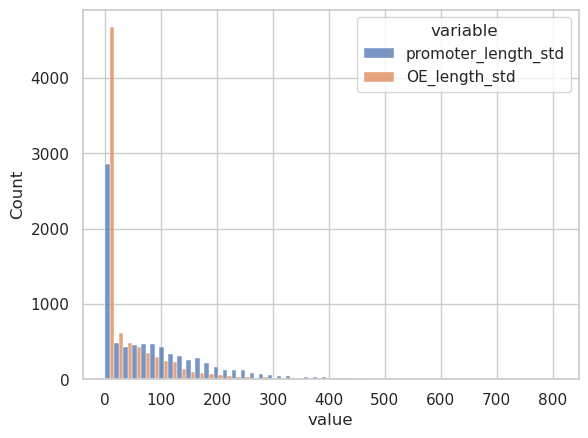

In [105]:
to_plot = per_sequence_with_ccmpra.select(["promoter", "OE", "promoter_length_std", "OE_length_std"]).unique().unpivot(index=["promoter", "OE"], on=["promoter_length_std", "OE_length_std"])
sns.histplot(to_plot.to_pandas(), x="value", hue="variable", bins=50, multiple="dodge")

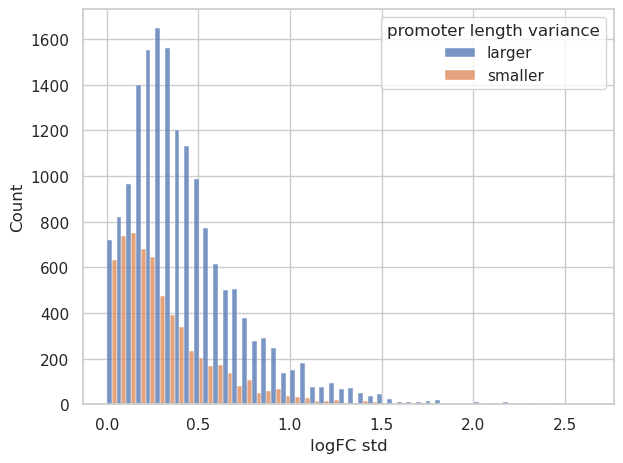

In [120]:
to_plot = per_sequence_with_ccmpra.with_columns(pl.when(pl.col("promoter_length_std") < 10).then(pl.lit("smaller")).otherwise(pl.lit("larger")).alias("promoter length variance"))
sns.histplot(to_plot.to_pandas(), x="std", hue="promoter length variance", bins=50, multiple="dodge")
plt.xlabel("logFC std")
plt.tight_layout()
plt.savefig(figdir+"/promoter_length_variance_vs_logFC_std.pdf", format="pdf")

In [147]:
per_sequence_with_ccmpra.filter(pl.col("OE") == "chr17-48907104-48907261-.")

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length,logFC,AveExpr,t,P.Value,adj.P.Val,B,std,var,logFC_ccmpra,adj.P.Val_ccmpra,P.Value_ccmpra,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std_ccmpra,z_score,promoter_length,OE_length,promoter_length_std,OE_length_std
str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,i64,i64,f64,f64
"""chr17-48907104-48907261-.""","""chr17-48908108-48908811-+""","""m84066_240623_102831_s3/208803162/ccs""","""chr17""",48907013,48907262,48908108,48908820,250,713,-0.923687,-0.924194,-4.718087,0.000008,0.000017,3.083969,0.285811,0.081688,-0.436753,0.002978,0.001867,15,4,"""yes""",null,"""pELS,CTCF-bound,PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""UBE2Z""","""target - other""","""PLS - ELS""",1277.0,"""UBE2Z""","""no effect""","""chr17-48908108-48908811-+""","""chr17-48907104-48907261-.""",-0.528171,0.371247,0.246248,713,250,0.707107,63.63961
"""chr17-48907104-48907261-.""","""chr17-48908108-48908811-+""","""m84066_240623_122801_s1/169411132/ccs""","""chr17""",48907104,48907263,48908108,48908819,160,712,-0.51949,-0.520015,-2.714835,0.007935,0.011257,-3.314098,0.285811,0.081688,-0.436753,0.002978,0.001867,15,4,"""yes""",null,"""pELS,CTCF-bound,PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""UBE2Z""","""target - other""","""PLS - ELS""",1277.0,"""UBE2Z""","""no effect""","""chr17-48908108-48908811-+""","""chr17-48907104-48907261-.""",-0.528171,0.371247,0.246248,712,160,0.707107,63.63961


In [123]:
to_plot.group_by("promoter length variance").agg(pl.col("std").median())

promoter length variance,std
str,f64
"""larger""",0.354639
"""smaller""",0.230639


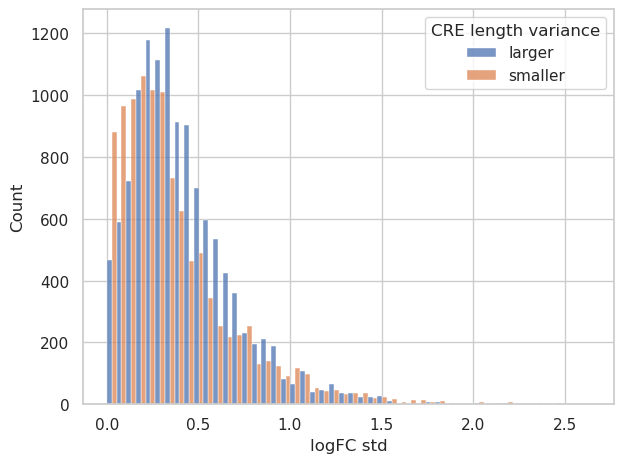

In [124]:
to_plot = per_sequence_with_ccmpra.with_columns(pl.when(pl.col("OE_length_std") < 10).then(pl.lit("smaller")).otherwise(pl.lit("larger")).alias("CRE length variance"))
sns.histplot(to_plot.to_pandas(), x="std", hue="CRE length variance", bins=50, multiple="dodge")
plt.xlabel("logFC std")
plt.tight_layout()
plt.savefig(figdir+"/CRE_length_variance_vs_logFC_std.pdf", format="pdf")

In [125]:
to_plot.group_by("CRE length variance").agg(pl.col("std").median())

CRE length variance,std
str,f64
"""larger""",0.356028
"""smaller""",0.283537


In [108]:
per_sequence_with_ccmpra.select(pl.corr("std", "promoter_length_std")), per_sequence_with_ccmpra.select(pl.corr("std", "OE_length_std"))

(shape: (1, 1)
 ┌──────────┐
 │ std      │
 │ ---      │
 │ f64      │
 ╞══════════╡
 │ 0.234088 │
 └──────────┘,
 shape: (1, 1)
 ┌─────────┐
 │ std     │
 │ ---     │
 │ f64     │
 ╞═════════╡
 │ 0.13329 │
 └─────────┘)

In [109]:
per_sequence_with_ccmpra.filter((pl.col("OE_length_std") > 5) 
								& (pl.col("OE_length_std") < 50) 
								& (pl.col("std") < 1.5)).sort("promoter", "OE").head() #.sort("std", descending=True).head(20)

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length,logFC,AveExpr,t,P.Value,adj.P.Val,B,std,var,logFC_ccmpra,adj.P.Val_ccmpra,P.Value_ccmpra,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std_ccmpra,z_score,promoter_length,OE_length,promoter_length_std,OE_length_std
str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,i64,i64,f64,f64
"""chr1-112616519-112616693-.""","""chr1-112619436-112619859-+""","""m84066_240623_102831_s3/260247055/ccs""","""chr1""",112616454,112616694,112619435,112619865,241,431,1.155267,1.156633,5.413257,5.6493e-7,0.000001,5.792433,0.257334,0.066221,0.848653,3.3798e-12,4.3991e-13,26,5,"""yes""",null,"""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""CAPZA1""","""target - other""",null,3041.5,"""CAPZA1""","""no effect""","""chr1-112619436-112619859-+""","""chr1-112616519-112616693-.""",0.709281,0.513952,0.271177,431,241,0.0,37.004504
"""chr1-112616519-112616693-.""","""chr1-112619436-112619859-+""","""m84066_240623_122801_s1/148705651/ccs""","""chr1""",112616457,112616701,112619435,112619865,245,431,0.943985,0.943996,6.333422,6.0780e-9,1.8914e-8,9.946097,0.257334,0.066221,0.848653,3.3798e-12,4.3991e-13,26,5,"""yes""",null,"""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""CAPZA1""","""target - other""",null,3041.5,"""CAPZA1""","""no effect""","""chr1-112619436-112619859-+""","""chr1-112616519-112616693-.""",0.709281,0.513952,0.271177,431,245,0.0,37.004504
"""chr1-112616519-112616693-.""","""chr1-112619436-112619859-+""","""m84066_240623_122801_s1/167777929/ccs""","""chr1""",112616522,112616700,112619435,112619865,179,431,0.6432,0.643989,3.957338,0.000136,0.000239,0.242157,0.257334,0.066221,0.848653,3.3798e-12,4.3991e-13,26,5,"""yes""",null,"""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""CAPZA1""","""target - other""",null,3041.5,"""CAPZA1""","""no effect""","""chr1-112619436-112619859-+""","""chr1-112616519-112616693-.""",0.709281,0.513952,0.271177,431,179,0.0,37.004504
"""chr1-112617488-112617622-.""","""chr1-112619436-112619859-+""","""m84066_240516_024507_s2/112134586/ccs""","""chr1""",112617491,112617660,112619435,112619864,170,430,0.5559,0.55769,2.735154,0.007574,0.010773,-3.182057,0.381494,0.145538,0.236882,0.032457,0.023789,38,3,"""yes""","""pELS,CTCF-bound""","""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""CAPZA1""","""target - other""","""PLS - ELS""",2092.5,"""CAPZA1""","""no effect""","""chr1-112619436-112619859-+""","""chr1-112617488-112617622-.""",0.709281,0.513952,-0.91915,430,170,2.12132,23.334524
"""chr1-112617488-112617622-.""","""chr1-112619436-112619859-+""","""m84066_240623_122801_s1/178651715/ccs""","""chr1""",112617491,112617627,112619435,112619867,137,433,0.016386,0.01388,0.140978,0.888051,0.90152,-7.486377,0.381494,0.145538,0.236882,0.032457,0.023789,38,3,"""yes""","""pELS,CTCF-bound""","""PLS,CTCF-bound""","""unlabeled""","""target""","""unlabeled""","""CAPZA1""","""target - other""","""PLS - ELS""",2092.5,"""CAPZA1""","""no effect""","""chr1-112619436-112619859-+""","""chr1-112617488-112617622-.""",0.709281,0.513952,-0.91915,433,137,2.12132,23.334524


In [110]:
subset = per_sequence_with_ccmpra.filter(
	(pl.col("OE_length_std") > 5) &
	(pl.col("OE_length_std") < 50) &
	(pl.col("std") < 1.5)
).with_columns(
	pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("start_left")).otherwise(pl.col("start_right")).alias("start_CRE"),
	pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("end_left")).otherwise(pl.col("end_right")).alias("end_CRE")
)

min_log = subset.select(pl.min("logFC")).item()
max_log = subset.select(pl.max("logFC")).item()

if max_log == min_log:
	subset = subset.with_columns(pl.lit(0).alias("logFC_scaled"))
else:
	subset = subset.with_columns(
		((pl.col("logFC") - min_log) / (max_log - min_log) * 1000).round().cast(pl.Int64).alias("logFC_scaled")
	)

subset.select("chrom", "start_CRE", "end_CRE", pl.concat_str(pl.lit("LogFC = "), pl.col("logFC").cast(pl.Utf8))) \
	.write_csv(cd + "results/manuscript_figures/revisions/variance_between_seqs_for_IGV.bed", separator="\t", include_header=False, quote_style=None)

In [111]:
promoter_subset = per_sequence_with_ccmpra.filter(
	(pl.col("promoter_length_std") > 5) &
	(pl.col("promoter_length_std") < 50) &
	(pl.col("std") < 1.5) &
	(pl.col("OE_length_std") < 5)
).with_columns(
	pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("start_left")).otherwise(pl.col("start_right")).alias("start_promoter"),
	pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("end_left")).otherwise(pl.col("end_right")).alias("end_promoter")
)

min_log = promoter_subset.select(pl.min("logFC")).item()
max_log = promoter_subset.select(pl.max("logFC")).item()

if max_log == min_log:
	promoter_subset = promoter_subset.with_columns(pl.lit(0).alias("logFC_scaled"))
else:
	promoter_subset = promoter_subset.with_columns(
		((pl.col("logFC") - min_log) / (max_log - min_log) * 1000).round().cast(pl.Int64).alias("logFC_scaled")
	)

promoter_subset.filter((np.sign(pl.col("logFC")) >= 0).all().over(["promoter", "OE"]))\
	.select("chrom", "start_promoter", "end_promoter", pl.concat_str(pl.lit("LogFC = "), pl.col("logFC").cast(pl.Utf8))) \
	.write_csv(cd + "results/manuscript_figures/revisions/variance_between_promoter_seqs_for_IGV.bed", separator="\t", include_header=False, quote_style=None)

In [112]:
pl.Config.set_tbl_rows(30)
promoter_subset.filter((np.sign(pl.col("logFC")) >= 0).all().over(["promoter", "OE"])).sort("std", descending=True).head()

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length,logFC,AveExpr,t,P.Value,adj.P.Val,B,std,var,logFC_ccmpra,adj.P.Val_ccmpra,P.Value_ccmpra,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std_ccmpra,z_score,promoter_length,OE_length,promoter_length_std,OE_length_std,start_promoter,end_promoter,logFC_scaled
str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,i64,i64,f64,f64,i64,i64,i64
"""chr1-153977585-153977954-.""","""chr1-153990702-153990831-+""","""m84066_240516_024507_s2/136514171/ccs""","""chr1""",153977585,153977961,153990665,153990833,377,169,1.158894,1.158241,7.572574,9.3266e-12,4.4737e-11,16.191932,1.226734,1.504877,2.003448,6.5085e-28,7.3793e-30,21,3,"""yes""","""PLS,CTCF-bound,pELS,CTCF-bound""","""PLS,CTCF-bound""","""unlabeled""","""positivecontrol""","""unlabeled""","""RPS27""","""positive - other""","""PLS - PLS""",12997.0,"""RPS27""","""no effect""","""chr1-153990702-153990831-+""","""chr1-153977585-153977954-.""",2.718566,0.532422,-1.34314,169,377,6.363961,2.828427,153990665,153990833,632
"""chr1-153977585-153977954-.""","""chr1-153990702-153990831-+""","""m84066_240623_122801_s1/173479385/ccs""","""chr1""",153977585,153977957,153990702,153990879,373,178,2.893758,2.895333,16.491703,7.0328e-30,5.6859e-28,57.254372,1.226734,1.504877,2.003448,6.5085e-28,7.3793e-30,21,3,"""yes""","""PLS,CTCF-bound,pELS,CTCF-bound""","""PLS,CTCF-bound""","""unlabeled""","""positivecontrol""","""unlabeled""","""RPS27""","""positive - other""","""PLS - PLS""",12997.0,"""RPS27""","""no effect""","""chr1-153990702-153990831-+""","""chr1-153977585-153977954-.""",2.718566,0.532422,-1.34314,178,373,6.363961,2.828427,153990702,153990879,969
"""chr1-153990832-153990874-+""","""chr1-153991430-153991768-.""","""m84066_240623_102831_s3/138608954/ccs""","""chr1""",153990702,153990880,153991433,153991777,179,345,2.967787,2.968201,18.966818,4.8374e-35,9.1189e-33,68.904115,1.142788,1.305964,2.199468,4.9965e-25,8.9131e-27,16,3,"""no""","""PLS,CTCF-bound""","""pELS,CTCF-bound,pELS""","""positivecontrol""","""unlabeled""","""RPS27""","""unlabeled""","""positive - other""","""PLS - ELS""",746.0,"""RPS27""","""no effect""","""chr1-153990832-153990874-+""","""chr1-153991430-153991768-.""",3.000752,1.044215,-0.767355,179,345,24.041631,0.707107,153990702,153990880,984
"""chr1-153990832-153990874-+""","""chr1-153991430-153991768-.""","""m84066_240623_102831_s3/92409694/ccs""","""chr1""",153990667,153990879,153991428,153991771,213,344,1.35164,1.352102,7.252115,1.3850e-10,5.5284e-10,13.796463,1.142788,1.305964,2.199468,4.9965e-25,8.9131e-27,16,3,"""no""","""PLS,CTCF-bound""","""pELS,CTCF-bound,pELS""","""positivecontrol""","""unlabeled""","""RPS27""","""unlabeled""","""positive - other""","""PLS - ELS""",746.0,"""RPS27""","""no effect""","""chr1-153990832-153990874-+""","""chr1-153991430-153991768-.""",3.000752,1.044215,-0.767355,213,344,24.041631,0.707107,153990667,153990879,670
"""chr17-82358938-82359289-+""","""chr17-82368032-82368304-.""","""m84066_240516_024507_s2/144703645/ccs""","""chr17""",82358938,82359224,82368032,82368307,287,276,0.642349,0.64406,3.731366,0.000323,0.000542,-0.431842,1.100565,1.211243,1.782784,7.1961e-41,1.0407e-43,34,5,"""yes""","""PLS,CTCF-bound""","""dELS,CTCF-bound""","""positivecontrol""","""unlabeled""","""TEX19""","""unlabeled""","""positive - other""","""PLS - ELS""",9054.5,"""TEX19""","""no effect""","""chr17-82358938-82359289-+""","""chr17-82368032-82368304-.""",1.377215,1.039761,0.39006,287,276,34.82815,1.154701,82358938,82359224,532


#### Checking if longer element also means higher activity

In [113]:
max_promoter = per_sequence_with_ccmpra.filter(pl.col("promoter_length_std") >= 10).filter(pl.col("OE_length_std") < 10).filter(pl.col("std") > 1) \
	.filter(pl.col("promoter_length") == pl.col("promoter_length").max().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "OE_length")
min_promoter = per_sequence_with_ccmpra.filter(pl.col("promoter_length_std") >= 10).filter(pl.col("OE_length_std") < 10).filter(pl.col("std") > 1) \
	.filter(pl.col("promoter_length") == pl.col("promoter_length").min().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "OE_length")
max_CRE = per_sequence_with_ccmpra.filter(pl.col("OE_length_std") >= 10).filter(pl.col("promoter_length_std") < 10).filter(pl.col("std") > 1) \
	.filter(pl.col("OE_length") == pl.col("OE_length").max().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "OE_length")
min_CRE = per_sequence_with_ccmpra.filter(pl.col("OE_length_std") >= 10).filter(pl.col("promoter_length_std") < 10).filter(pl.col("std") > 1) \
	.filter(pl.col("OE_length") == pl.col("OE_length").min().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "OE_length")

In [114]:
minmax_promoter = max_promoter.join(min_promoter, on=["left_bin", "right_bin"], suffix="_min") \
	.with_columns(
	pl.when(pl.col("logFC") > pl.col("logFC_min")).then(pl.lit("longer higher")).when(pl.col("logFC") == pl.col("logFC_min")).then(pl.lit("equal")) \
		.otherwise(pl.lit("shorter higher")).alias("length_effect_promoter"),
)

minmax_CRE = max_CRE.join(min_CRE, on=["left_bin", "right_bin"], suffix="_min") \
	.with_columns(
	pl.when(pl.col("logFC") > pl.col("logFC_min")).then(pl.lit("longer higher")).when(pl.col("logFC") == pl.col("logFC_min")).then(pl.lit("equal")) \
		.otherwise(pl.lit("shorter higher")).alias("length_effect_CRE")
	)

minmax = pl.DataFrame({
	"length_effect": ["longer higher", "shorter higher", "longer higher", "shorter higher"],
	"count": [
		minmax_promoter.filter(pl.col("length_effect_promoter") == "longer higher").height,
		minmax_promoter.filter(pl.col("length_effect_promoter") == "shorter higher").height,
		minmax_CRE.filter(pl.col("length_effect_CRE") == "longer higher").height,
		minmax_CRE.filter(pl.col("length_effect_CRE") == "shorter higher").height,
	],
	"element": ["promoter"] * 2 + ["CRE"] * 2
})

In [115]:
minmax_promoter.height, minmax_CRE.height

(223, 32)

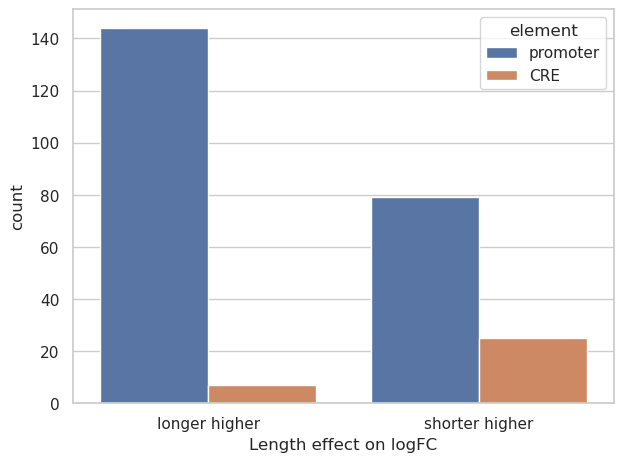

In [116]:
sns.set_theme(style="whitegrid")
sns.barplot(data=minmax.to_pandas(), x="length_effect", y="count", hue="element")
plt.tight_layout()
plt.xlabel("Length effect on logFC")
plt.savefig(figdir+"/length_effect_on_logFC.pdf", format="pdf")

In [117]:
max_logFC_promoter = per_sequence_with_ccmpra.filter(pl.col("std") > 1).filter(pl.col("OE_length_std") < 10).filter(pl.col("promoter_length_std") >= 10) \
	.filter(pl.col("logFC") == pl.col("logFC").max().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "chrom", "start_left", "end_left", "start_right", "end_right", "promoter") \
		.with_columns(promoter_start = pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("start_left")).otherwise(pl.col("start_right")), 
			promoter_end = pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("end_left")).otherwise(pl.col("end_right")) )
min_logFC_promoter = per_sequence_with_ccmpra.filter(pl.col("std") > 1).filter(pl.col("OE_length_std") < 10).filter(pl.col("promoter_length_std") >= 10) \
	.filter(pl.col("logFC") == pl.col("logFC").min().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "chrom", "start_left", "end_left", "start_right", "end_right", "promoter") \
		.with_columns(promoter_start = pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("start_left")).otherwise(pl.col("start_right")), 
			promoter_end = pl.when(pl.col("left_bin") == pl.col("promoter")).then(pl.col("end_left")).otherwise(pl.col("end_right")) )
max_logFC_CRE = per_sequence_with_ccmpra.filter(pl.col("std") > 1).filter(pl.col("promoter_length_std") < 10).filter(pl.col("OE_length_std") >= 10) \
	.filter(pl.col("logFC") == pl.col("logFC").max().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "chrom", "start_left", "end_left", "start_right", "end_right", "OE") \
		.with_columns(OE_start = pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("start_left")).otherwise(pl.col("start_right")), 
			OE_end = pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("end_left")).otherwise(pl.col("end_right")) )
min_logFC_CRE = per_sequence_with_ccmpra.filter(pl.col("std") > 1).filter(pl.col("promoter_length_std") < 10).filter(pl.col("OE_length_std") >= 10) \
	.filter(pl.col("logFC") == pl.col("logFC").min().over(["left_bin", "right_bin"])).select("logFC", "left_bin", "right_bin", "seq_id", "chrom", "start_left", "end_left", "start_right", "end_right", "OE") \
		.with_columns(OE_start = pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("start_left")).otherwise(pl.col("start_right")), 
			OE_end = pl.when(pl.col("left_bin") == pl.col("OE")).then(pl.col("end_left")).otherwise(pl.col("end_right")) )

In [118]:
max_logFC_promoter.select("chrom", "promoter_start", "promoter_end").write_csv(
	cd + "results/manuscript_figures/revisions/enrichment_differences_sequences/promoter_max_logFC.bed", separator="\t", include_header=False, quote_style=None)
min_logFC_promoter.select("chrom", "promoter_start", "promoter_end").write_csv(
	cd + "results/manuscript_figures/revisions/enrichment_differences_sequences/promoter_min_logFC.bed", separator="\t", include_header=False, quote_style=None)
max_logFC_CRE.select("chrom", "OE_start", "OE_end").write_csv(
	cd + "results/manuscript_figures/revisions/enrichment_differences_sequences/CRE_max_logFC.bed", separator="\t", include_header=False, quote_style=None)
min_logFC_CRE.select("chrom", "OE_start", "OE_end").write_csv(
	cd + "results/manuscript_figures/revisions/enrichment_differences_sequences/CRE_min_logFC.bed", separator="\t", include_header=False, quote_style=None)	

## H3k4me3 stratified analysis

In [23]:
H3K4me3 = pl.read_csv(cd + "results/manuscript_figures/revisions/stratified_distances_H3K4me3_zscores.tsv", separator="\t", skip_lines=1, has_header=False,
			new_columns=["category", "H3K4me3_enrichment", "pvalue"])

In [119]:
to_plot = H3K4me3.with_columns(pl.col("category").str.split("_")) \
	.with_columns(
		element = pl.col("category").list.get(0),
		distance = pl.col("category").list.get(-1).cast(pl.Int64)
	).with_columns(
		element = 
		pl.when(pl.col("element") == "Upregulating").then(pl.lit("Enhancer")) 
		.when(pl.col("element") == "Downregulating").then(pl.lit("Silencer"))
		.otherwise(pl.lit("Neutral")),
		distance = 
		pl.when(pl.col("distance") == 1).then(pl.lit("< 2kb"))
		.when(pl.col("distance") == 2).then(pl.lit("2-5kb"))
		.when(pl.col("distance") == 3).then(pl.lit("5-10kb"))
		.when(pl.col("distance") == 4).then(pl.lit("10-20kb"))
		.when(pl.col("distance") == 5).then(pl.lit(">= 20kb")),
		significance = pl.when(pl.col("pvalue") < 0.05).then(pl.lit("Significant"))
		.otherwise(pl.lit("Not significant"))
	) \
	.select(["element", "distance", "H3K4me3_enrichment", "pvalue", "significance"])

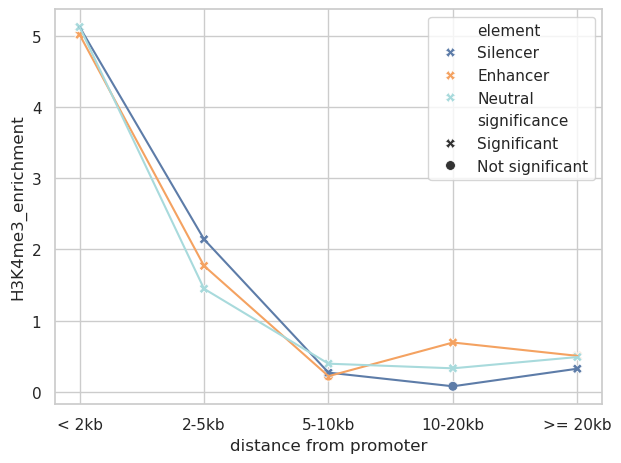

In [136]:
sns.lineplot(data=to_plot.to_pandas(), x="distance", y="H3K4me3_enrichment", hue="element", legend=False,
			 hue_order=["Silencer", "Enhancer", "Neutral"], palette=["#5D7CA8", "#F4A261", "#A8DADC"])
sns.scatterplot(data=to_plot.to_pandas(), x="distance", y="H3K4me3_enrichment", hue="element", style="significance"
				, style_order=["Significant", "Not significant"], markers=["X", "o"], s=50, 
				hue_order=["Silencer", "Enhancer", "Neutral"], palette=["#5D7CA8", "#F4A261", "#A8DADC"])
#plt.legend(title="Element type", labels=["Enhancer", "Silencer", "Neutral"])
plt.tight_layout()
plt.xlabel("distance from promoter")
plt.savefig(figdir+"/H3K4me3_enrichment_vs_distance.pdf", format="pdf")

# I manually edited the legend of this plot in inksckape for more clarity

## What's up with the TOMM6 from the luciferase

In [3]:
mpra.filter(pl.col("promoter") == "chr6-41787436-41787975-+").filter(pl.col("OE") 
== "chr6-42043482-42043608-.")


logFC,adj.P.Val,P.Value,left_bin,right_bin,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std,z_score
f64,f64,f64,str,str,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64
1.044954,2.7559e-7,9.0240e-8,"""chr6-41787436-41787975-+""","""chr6-42043482-42043608-.""",7,2,"""yes""","""PLS,CTCF-bound,pELS,CTCF-bound""","""dELS""","""target""","""unlabeled""","""TOMM6""","""unlabeled""","""target - other""","""PLS - ELS""",255839.5,"""TOMM6""","""no effect""","""chr6-41787436-41787975-+""","""chr6-42043482-42043608-.""",0.463298,0.309518,1.87923


In [53]:
per_sequence_with_ccmpra.filter(pl.col("OE") == "chr6-41768791-41769144-.")

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right,left_length,right_length,logFC,AveExpr,t,P.Value,adj.P.Val,B,std,var,logFC_ccmpra,adj.P.Val_ccmpra,P.Value_ccmpra,nr_reads,nr_seqs,any_tss,screen_left,screen_right,targeted_left,targeted_right,target_gene_left,target_gene_right,label,interaction,dist,target_genes,effect,promoter,OE,promoter_only,std_ccmpra,z_score,promoter_length,OE_length,promoter_length_std,OE_length_std
str,str,str,str,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,i64,i64,f64,f64


## RNA expression per nr of interacting CREs

In [132]:
RNA = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/manuscript_figures/revisions/rna_seq_multi_interact/genes_with_TPM.tsv", separator="\t"
				  , has_header=False, new_columns=["gene_ID", "TPM", "gene_name"]) \
				  .with_columns(log_TPM = np.log2(pl.col("TPM") + 1))

In [133]:
multi_prom = mpra.group_by('target_genes', 'OE').agg(pl.col("z_score").median()).join(
	RNA, left_on="target_genes", right_on="gene_name") \
		.with_columns(multi_prom_count = pl.col("target_genes").len().over("OE")) \
.group_by("gene_ID", "target_genes").agg(
	pl.col("multi_prom_count").max(),
	pl.col("z_score").median(),
	pl.col("log_TPM").first()
).sort(["multi_prom_count", "log_TPM"], descending=True)

In [21]:
multi_prom.select("target_genes", "gene_ID", "multi_prom_count").write_csv(
	cd + "results/manuscript_figures/revisions/rna_seq_multi_interact/multiple_promoter_interacting_genes.tsv", separator="\t", quote_style=None)

(-1.0, 532.0)

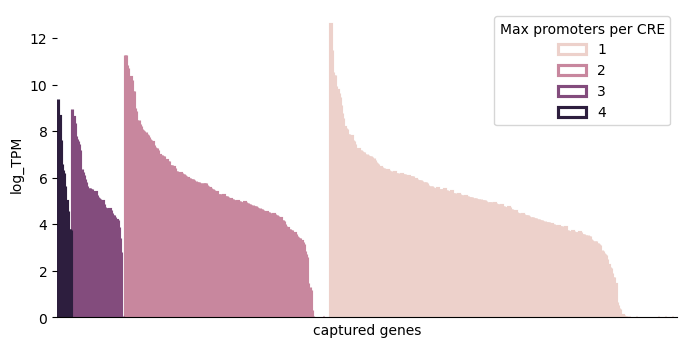

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=multi_prom.to_pandas(), x="gene_ID", y="log_TPM", hue="multi_prom_count", 
	width=0.1, fill=False)
plt.xticks([])
plt.xlabel("captured genes")
plt.legend(title="Max promoters per CRE")
sns.despine(left=True)
plt.xlim(-1, multi_prom.height)

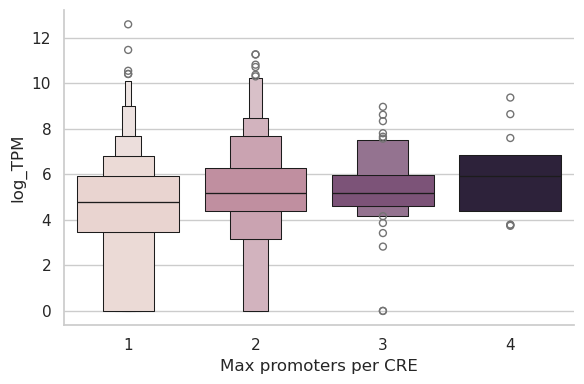

In [134]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxenplot(data=multi_prom.to_pandas(), x="multi_prom_count", y="log_TPM", hue="multi_prom_count", legend=False)
plt.xlabel("Max promoters per CRE")
sns.despine()

#plt.legend(title="Max promoters per CRE")
plt.tight_layout()
plt.savefig(figdir+"/multi_promoter_interacting_CREs_vs_log_TPM.pdf", format="pdf")

In [142]:
from scipy import stats

result12 = stats.ttest_ind(
	multi_prom.filter(pl.col("multi_prom_count") == 1).select("log_TPM").to_numpy().flatten(), 
	multi_prom.filter(pl.col("multi_prom_count") == 2).select("log_TPM").to_numpy().flatten())
result13 = stats.ttest_ind(
	multi_prom.filter(pl.col("multi_prom_count") == 1).select("log_TPM").to_numpy().flatten(), 
	multi_prom.filter(pl.col("multi_prom_count") == 3).select("log_TPM").to_numpy().flatten())
result14 = stats.ttest_ind(
	multi_prom.filter(pl.col("multi_prom_count") == 1).select("log_TPM").to_numpy().flatten(), 
	multi_prom.filter(pl.col("multi_prom_count") == 4).select("log_TPM").to_numpy().flatten())

print(f"t-test results 1 vs 2: t-statistic = {result12.statistic:.4f}, p-value = {result12.pvalue:.4e}, df = {result12.df:.0f}")
print(f"t-test results 1 vs 3: t-statistic = {result13.statistic:.4f}, p-value = {result13.pvalue:.4e}, df = {result13.df:.0f}")
print(f"t-test results 1 vs 4: t-statistic = {result14.statistic:.4f}, p-value = {result14.pvalue:.4e}, df = {result14.df:.0f}")

t-test results 1 vs 2: t-statistic = -3.4103, p-value = 7.0440e-04, df = 473
t-test results 1 vs 3: t-statistic = -2.2970, p-value = 2.2225e-02, df = 341
t-test results 1 vs 4: t-statistic = -2.1109, p-value = 3.5589e-02, df = 308


## Analyze luciferase

In [5]:
luciferase = pl.read_excel(os.path.join(cd, "results/manuscript_figures/revisions/luciferase/recap_with_ccmpra.xlsx")) \
.select(name = pl.col("__UNNAMED__0"), normalized_activity = pl.col("__UNNAMED__12").cast(pl.Float64, strict=False)) \
.with_columns(bin = pl.col("name").str.replace("_.*", "" )) \
.filter(pl.col("normalized_activity").is_not_null())

Could not determine dtype for column 8, falling back to string


In [6]:
dfs = luciferase.partition_by("bin")

## Hi-C vs DNA count outliers

In [14]:
DNA_counts = pl.read_csv(os.path.join(cd, "results/Hi-C_outliers_vs_DNA_counts/DNA_counts_formatted.tsv.gz"), 
						 separator="\t", has_header=False, new_columns=["otherEndID", "baitID", "DNA_count"])
HiC_counts = pl.read_csv(os.path.join(cd, "results/manuscript_figures/figure4/hic_counts.tsv.gz"), 
									  separator="\t", skip_lines=1)

In [21]:
DNA_vs_HiC = DNA_counts.join(HiC_counts, on=["otherEndID", "baitID"]).with_columns(
	logDNA = np.log2(pl.col("DNA_count") + 1),
	logHiC = np.log2(pl.col("N") + 1)
)

<Axes: xlabel='logDNA', ylabel='logHiC'>

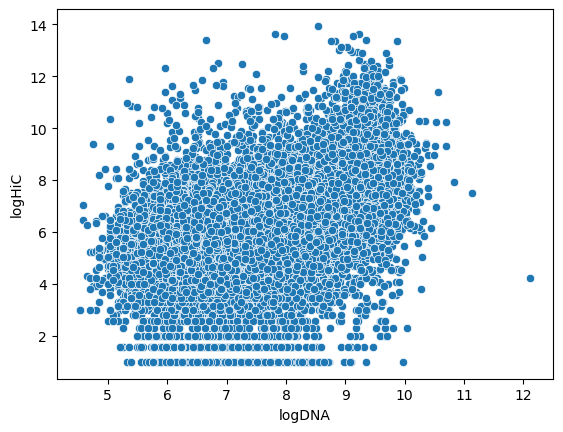

In [22]:
sns.scatterplot(DNA_vs_HiC.to_pandas(), x="logDNA", y="logHiC")

In [ ]:
DNA_vs_HiC.select(pl.corr("logDNA", "logHiC"))

: 

In [36]:
quartiles = DNA_vs_HiC.with_columns(HiC_IQR = (pl.col("N") - pl.col("N").median()) 
									 / (pl.col("N").quantile(0.75) - pl.col("N").quantile(0.25)))
quartiles = quartiles.with_columns(
									 pl.when(pl.col("HiC_IQR") > 1.5).then(pl.lit("outliers"))
									 .when(pl.col("N") < pl.col("N").quantile(0.25))
									 .then(pl.lit("first"))
									 .when((pl.col("N") > pl.col("N").quantile(0.25))
									 & (pl.col("N") < pl.col("N").median()))
									 .then(pl.lit("second"))
									 .when((pl.col("N") > pl.col("N").median())
									 & (pl.col("N") < pl.col("N").quantile(0.75)))
									 .then(pl.lit("third"))
									 .when((pl.col("N") > pl.col("N").quantile(0.75))
									 & (pl.col("HiC_IQR") <= 1.5))
									 .then(pl.lit("fourth"))
									.alias("HiC quartiles")) 

In [ ]:
sns.set_style("whitegrid")
sns.boxplot(data=quartiles.to_pandas(), x="HiC quartiles", y="logDNA", order=["first", "second", "third", "fourth", "outliers"])
plt.tight_layout()
plt.savefig(figdir+"/HiC_quartiles_vs_logDNA_counts.pdf", format="pdf")

: 